In [1]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import*
from numpy.polynomial.hermite import hermgauss
from scipy.special import eval_hermite, factorial

In [ ]:
def sf_protocol(eta, var, key_len):

    bob_bitstr = []
    alice_bitstr = []
    for i in range(key_len):
        prog = sf.Program(2)
        theta = np.arccos(np.sqrt(eta))
        with prog.context as q:

            Vac | q[0]
            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))
            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            Vac | q[1]
            
            BSgate(theta, 0.0) | (q[0], q[1])

            x = np.random.randint(0, 2)
            if x==0:
                MeasureHomodyne(0) | q[0]
                alice_bitstr.append(alpha_q)
                
            else:
                MeasureHomodyne(np.pi/2) | q[0]
                alice_bitstr.append(alpha_p)

        eng = sf.Engine("gaussian")
        result = eng.run(prog)
        bob_bitstr.append(result.samples[0][0])
        eng.reset()

    return alice_bitstr, bob_bitstr



In [72]:
def holevo_bound(lambda1, lambda2):

    def G(x):

        if x==0:
            return 0
        return  (x + 1)*np.log2(x + 1) - x*np.log2(x)
    
    return G((lambda1 - 1)/2) - G((lambda2 - 1)/2)


def lambda_RR(var_a, eta):

    #lambda1 = 1+(1-eta)*var_a
    #lambda2 = np.sqrt((1+(1-eta)*var_a)*(1+(1-eta)*var_a/(1+eta*var_a)))

    V1 = var_a+1+np.sqrt(2*var_a+var_a**2)
    V2 = var_a+1-np.sqrt(2*var_a+var_a**2)

    VB_p = 1/(2*V1)+1/(2*V2)
    VB_x = (V1+V2)/2
    CBE_x = np.sqrt(eta*(1-eta))*(1-VB_x)

    lambda1 = np.sqrt(VB_x*(1-eta)+eta)*np.sqrt(VB_p*(1-eta)+eta)
    lambda2 =  np.sqrt((VB_x*(1-eta)+eta-CBE_x**2/(VB_x*eta+1-eta))*(VB_p*(1-eta)+eta))

    return lambda1, lambda2


def lambda_DR(var_a, eta):

    lambda1 = 1+(1-eta)*var_a
    lambda2 = 1

    return lambda1, lambda2


def I_theory(var_a, eta):
    return 1/2*np.log2(1+(var_a*eta)/(1+eta*(1-1)))


def key_rate(b, I, x):
    return b*np.array(I)-np.array(x)



## RR

Holevo Calculation using SF

In [83]:
def eve_state_RR(eta, var, key_len, cutoff=20, nbins=30):

    theta = np.arccos(np.sqrt(eta))

    # First store Eve states and Bob outcomes
    eve_states = []
    bob_results = []

    for i in range(key_len):

        prog = sf.Program(2)

        with prog.context as q:

            Vac | q[0]

            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))

            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            Vac | q[1]

            BSgate(theta, 0.0) | (q[0], q[1])

            # For RR, Bob measures one quadrature
            MeasureHomodyne(0) | q[0]

        eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})

        result = eng.run(prog)

        # Bob's homodyne result
        b = result.samples[0][0]

        # Eve's conditional state after Bob's measurement
        rho_E_i = result.state.reduced_dm([1])

        bob_results.append(b)
        eve_states.append(rho_E_i)

        eng.reset()

    bob_results = np.array(bob_results)

    # ------------------------------------------------
    # Unconditional Eve state
    # ------------------------------------------------

    rho_E = np.mean(eve_states, axis=0)

    S_E = von_neumann_entropy(rho_E)

    # ------------------------------------------------
    # Bin Bob's results
    # ------------------------------------------------

    bins = np.linspace(
        np.min(bob_results),
        np.max(bob_results),
        nbins + 1)

    S_E_given_B = 0.0

    for j in range(nbins):

        if j == nbins - 1:
            indices = np.where(
                (bob_results >= bins[j]) &
                (bob_results <= bins[j+1]))[0]
        else:
            indices = np.where(
                (bob_results >= bins[j]) &
                (bob_results < bins[j+1]))[0]

        if len(indices) == 0:
            continue

        # Conditional Eve density matrix for this bin
        rho_E_b = np.mean(
            [eve_states[i] for i in indices],
            axis=0)

        # Probability of this Bob bin
        p_b = len(indices) / key_len

        # Entropy of conditional Eve state
        S_E_b = von_neumann_entropy(rho_E_b)

        S_E_given_B += p_b * S_E_b

    chi_EB = S_E - S_E_given_B

    return rho_E, chi_EB

In [84]:
eta = 0.1
key_len = 1500
size = 5
sigma_grid = np.linspace(0,10,size)
holevo_grid=np.zeros((size))
for i, sigma in enumerate(sigma_grid):
    rho_E, chi_EB = eve_state_RR(eta, sigma**2, key_len)
    holevo_grid[i] = chi_EB
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)
    

KeyboardInterrupt: 

SKR Calculation

In [ ]:
eta = 0.1
keylen=10000
size = 51
sigma_grid = np.linspace(0,10,size)
I_grid = np.zeros((size))
holevo_th_grid = np.zeros((size))

for i,sigma in enumerate(sigma_grid):
    alice_bitstr, bob_bitstr = sf_protocol(eta, sigma**2, keylen)
    rho = np.corrcoef(alice_bitstr, bob_bitstr)[0, 1]
    I_AB = -0.5 * np.log2(1 - rho**2)
    I_grid[i] = I_AB
    holevo_th_grid[i] = holevo_bound(*lambda_RR(sigma**2, eta))
    
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

    
    

Progress: 1/51

c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
c:\Users\kmits\Desktop\github\Quantum-Communications-Internship-IRIDA-\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide


Progress: 51/51

"\nb = 0.95\nfig = plt.figure(figsize=(10,5), dpi=100)\nplt.plot(sigma_grid**2, key_rate(b, I_theory(sigma_grid, eta), holevo_grid), 'k', label = f'Key-Rate for b={b}')\nplt.scatter(sigma_grid**2, key_rate(b, I_grid, holevo_grid), s=15, color = 'magenta', label = f'MC Key-Rate for b={b}')\nplt.xlabel(r'$Var_{{\x07lpha}}$', fontsize=15)\nplt.ylim(0)\nplt.ylabel(r'$K$', fontsize=15)\nplt.legend(fontsize=15)\n"

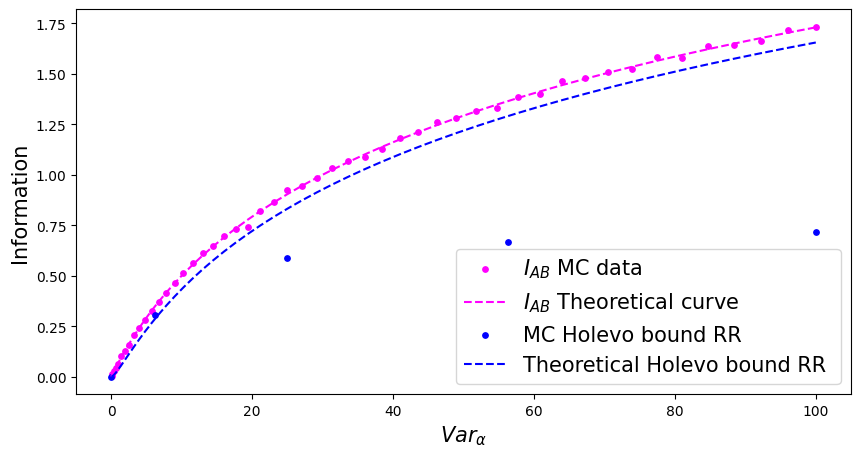

In [ ]:
b = 0.95
sigma_grid2 = np.linspace(0,10,5)
size = 51
sigma_grid = np.linspace(0,10,size)
fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(sigma_grid**2, I_grid, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
plt.plot(sigma_grid**2, I_theory(sigma_grid**2, eta), '--', color='magenta', label=r'$I_{AB}$ Theoretical curve')
plt.scatter(sigma_grid2**2, holevo_grid, s=15, color = 'blue', label = 'MC Holevo bound RR')
plt.plot(sigma_grid**2, holevo_th_grid, 'b--', label = 'Theoretical Holevo bound RR ')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)

b = 0.95
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(sigma_grid**2, key_rate(b, I_theory(sigma_grid, eta), holevo_th_grid), 'k', label = f'Key-Rate for b={b}')
plt.scatter(sigma_grid**2, key_rate(b, I_grid, holevo_th_grid), s=15, color = 'magenta', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)


## DR

Holevo bound calculation using SF

In [ ]:
def eve_state_DR(eta, var, key_len):
    cutoff = 20
    rho_E = np.zeros((cutoff, cutoff), dtype=complex)
    for i in range(key_len):
        prog = sf.Program(2)
        theta = np.arccos(np.sqrt(eta))
        with prog.context as q:

            # Input state on Alice's mode
            Vac | q[0]
            alpha_p = np.random.normal(0, np.sqrt(var))
            alpha_q = np.random.normal(0, np.sqrt(var))
            Xgate(alpha_q) | q[0]
            Zgate(alpha_p) | q[0]

            # Vacuum entering unused beam-splitter port
            Vac | q[1]
            # Beam splitter
            BSgate(theta, 0.0) | (q[0], q[1])

        eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff})
        result = eng.run(prog)
        rho_E += result.state.reduced_dm([1])/key_len
        eng.reset()

    def von_neumann_entropy(rho):
        eigvals = np.linalg.eigvalsh(rho)

        # Remove numerical noise
        eigvals = eigvals[eigvals > 1e-12]

        return -np.sum(eigvals * np.log2(eigvals))

    return von_neumann_entropy(rho_E)


0.2452465815198106


In [98]:
eta = 0.6
key_len = 10000
sigma_grid = np.linspace(0,10,5)
holevo_grid=np.zeros((5))
for i, sigma in enumerate(sigma_grid):
    chi_EA = eve_state_DR(eta, sigma**2, key_len)
    holevo_grid[i] = chi_EA
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)
    

Progress: 5/5

SKR Calculation

In [87]:
eta = 0.6
keylen=10000
size = 51
sigma_grid = np.linspace(0,10,size)
I_grid = np.zeros((size))
holevo_th_grid=np.zeros((size))
for i,sigma in enumerate(sigma_grid):
    alice_bitstr, bob_bitstr = sf_protocol(eta, sigma**2, keylen)
    rho = np.corrcoef(alice_bitstr, bob_bitstr)[0, 1]
    I_AB = -0.5 * np.log2(1 - rho**2)
    I_grid[i] = I_AB
    holevo_th_grid[i] = holevo_bound(*lambda_DR(sigma**2, eta))
    
    print(f"\rProgress: {i+1}/{len(sigma_grid)}", end="", flush=True)

    
    

Progress: 51/51

5


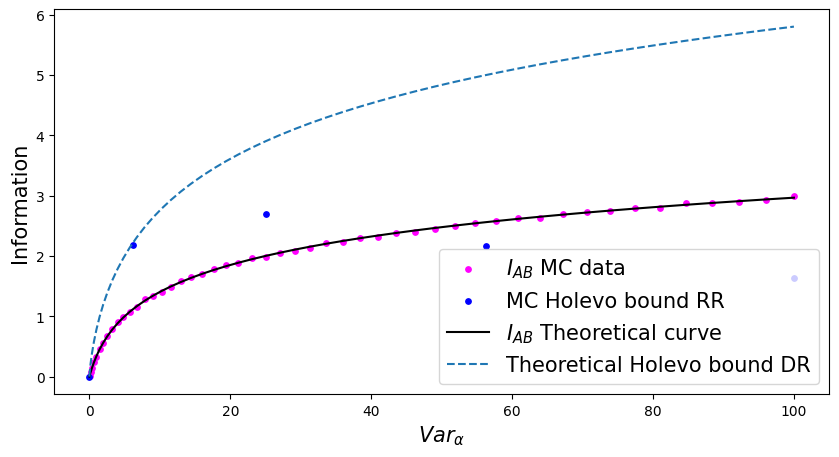

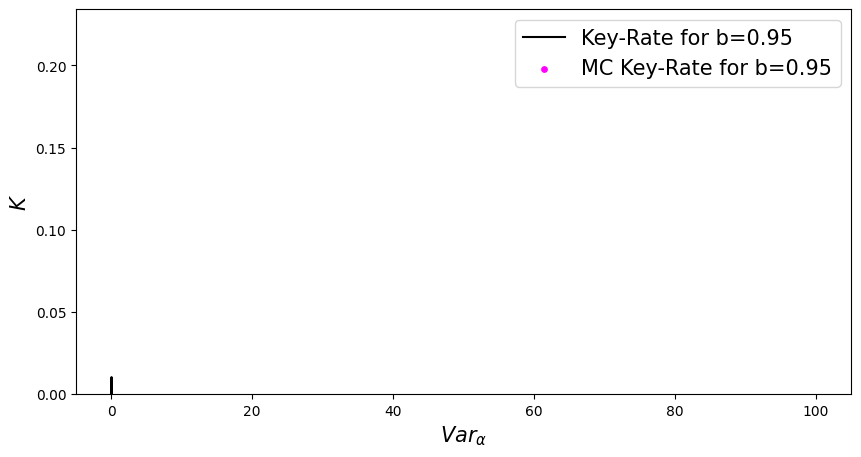

In [99]:
b = 0.95
size = 51
sigma_grid2 = np.linspace(0,10,5)
sigma_grid = np.linspace(0,10,size)
fig = plt.figure(figsize=(10,5), dpi=100)
plt.scatter(sigma_grid**2, I_grid, s=15, color = 'magenta', label=r'$I_{AB}$ MC data')
print(np.size(holevo_grid))
plt.scatter(sigma_grid2**2, holevo_grid[:5], s=15, color = 'blue', label = 'MC Holevo bound RR')
plt.plot(sigma_grid**2, I_theory(sigma_grid**2, eta), 'k', label=r'$I_{AB}$ Theoretical curve')
plt.plot(sigma_grid**2, holevo_th_grid, '--', label = 'Theoretical Holevo bound DR')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylabel(r'Information', fontsize=15)
plt.legend(fontsize=15)


b = 0.95
fig = plt.figure(figsize=(10,5), dpi=100)
plt.plot(sigma_grid**2, key_rate(b, I_theory(sigma_grid, eta), holevo_th_grid), 'k', label = f'Key-Rate for b={b}')
plt.scatter(sigma_grid**2, key_rate(b, I_grid, holevo_th_grid), s=15, color = 'magenta', label = f'MC Key-Rate for b={b}')
plt.xlabel(r'$Var_{{\alpha}}$', fontsize=15)
plt.ylim(0)
plt.ylabel(r'$K$', fontsize=15)
plt.legend(fontsize=15)
